### 1.参数的更新方法

我们知道神经网络学习的目的是找到合适的参数，寻找最优参数的过程叫做最优化，但是这个过程是非常困难的，不能通过公式一步到位，只能通过一些方法逐渐得到，之前接触过SGD(随机梯度下降法)，它有它的优点，但也有其局限性

例如：f(x,y)=1/20*x²+y²，在求这个函数最值时，SGD就显得十分低效，因为其在一个方向上的梯度相当大，而另一个方向上的梯度又很小，而它低效的根本原因是梯度并没有指向最小值的位置。为了适应不同的问题类型，有其他几种方法可以使用

- Momentum

$$
v \leftarrow \alpha v - \eta \nabla_w L(w)
$$

$$
w \leftarrow w + v
$$

η同样表示学习率，是我们的超参数，l(w)表示的是损失函数关于w权重的梯度，这里出现新的变量v表示物理里的速度，同时出现了αv这个式子，其中α取0.9这样的值，承担在不受任何力时，使物体逐渐减速的任务，对应摩擦力或空气阻力，下面是代码实现

In [ ]:
from random import shuffle

import numpy as np


class Momentum:
    def __init__(self,lr=0.01,momentum=0.9):
        self.lr = lr
        self.momentum = momentum
        self.v=None
    def update(self,params,grads):
        if self.v is None:
            self.v={}#字典变量，键值对
            for key,val in params.items():#params也是字典变量，key保存名字，val保存数值
                self.v[key]=np.zeros_like(val)
        for key in params.keys():
            self.v[key]=self.momentum*self.v[key]-self.lr*grads[key]
            params[key]+=self.v[key]

可以将SGD比作走一步看一步，当函数复杂时，很容易原地打转且陷入鞍点，但是Momentum不一样，它在持续积累，即使某一方向的梯度很小，但是方向没有改变时，其速度会越来越快，且即使当梯度为零时，也可以依靠之前积累的惯性继续学习

- AdaGrad

学习率是一个非常重要的超参数，太小导致学习效率低下，太大导致学习不精准，那可不可以让其在学习过程中开始较大，后面逐渐缩小呢，是可以的，就是AdaGrad方法

### 1. 累加历史梯度的平方
$$
s_t = s_{t-1} + (\nabla_w L(w))^2
$$

### 2. 更新权重参数
$$
w \leftarrow w - \frac{\eta}{\sqrt{s_t + \epsilon}} \odot \nabla_w L(w)
$$

---

### 📝 符号说明
* $w$：权重参数 (Weight)
* $L(w)$：损失函数 (Loss)
* $\nabla_w L(w)$：当前梯度
* $s_t$：历史梯度平方和
* $\eta$：全局学习率
* $\epsilon$：防止分母为0的极小常数 (如 $10^{-8}$)
* $\odot$：按元素相乘

由公式：当梯度较大时，反而w更新时的参数分母很大，所以变化较大的元素学习率会变小。

但是，由于会记录历史梯度的平方和，持续学习中，最后更新量会变为零导致无法学习，为了改善，可以使用RMSProp方法，它不会将过去的梯度一视同仁的加起来，而是逐渐遗忘过去的梯度，在做加法运算时更多的展现新梯度的信息，这种操作叫做“指数移动平均”，呈指数函数式地减小过去的梯度

In [ ]:
class AdaGrad:
    def __init__(self,lr=0.01,):
        self.lr = lr
        self.h=None
    def update(self,params,grads):
        if self.h is None:
            self.h={}
            for key,val in params.items():
                self.h[key]=np.zeros_like(val)

            for key in params.keys():
                self.h[key]+=grads[key]*grads[key]
                params[key]-=self.lr*grads[key]/(np.sqrt(np.sum(self.h[key]))+1e-7)#防止除数为零

- Adam方法

同时结合Momentum和AdaGrad，设置了三个超参数，这里不再赘述

### 方法的选择

通过下面这段代码，我们可以可视化的看见几种方法的不同

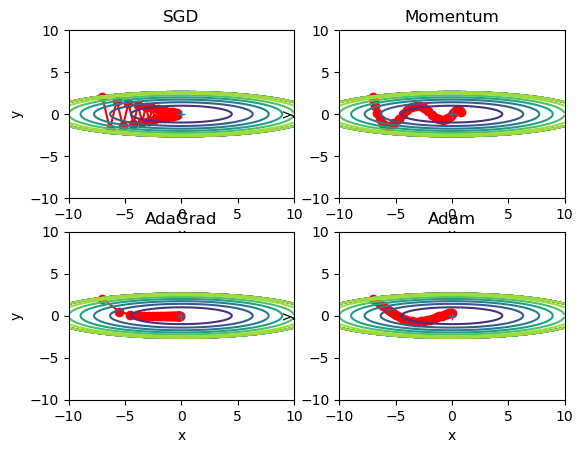

In [1]:

import sys, os
sys.path.append(os.pardir)  #
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict
from common.optimizer import *


def f(x, y):
    return x**2 / 20.0 + y**2


def df(x, y):
    return x / 10.0, 2.0*y

init_pos = (-7.0, 2.0)
params = {}
params['x'], params['y'] = init_pos[0], init_pos[1]
grads = {}
grads['x'], grads['y'] = 0, 0


optimizers = OrderedDict()
optimizers["SGD"] = SGD(lr=0.95)
optimizers["Momentum"] = Momentum(lr=0.1)
optimizers["AdaGrad"] = AdaGrad(lr=1.5)
optimizers["Adam"] = Adam(lr=0.3)

idx = 1

for key in optimizers:
    optimizer = optimizers[key]
    x_history = []
    y_history = []
    params['x'], params['y'] = init_pos[0], init_pos[1]

    for i in range(30):
        x_history.append(params['x'])
        y_history.append(params['y'])

        grads['x'], grads['y'] = df(params['x'], params['y'])
        optimizer.update(params, grads)


    x = np.arange(-10, 10, 0.01)
    y = np.arange(-5, 5, 0.01)

    X, Y = np.meshgrid(x, y)
    Z = f(X, Y)

    # for simple contour line
    mask = Z > 7
    Z[mask] = 0

    # plot
    plt.subplot(2, 2, idx)
    idx += 1
    plt.plot(x_history, y_history, 'o-', color="red")
    plt.contour(X, Y, Z)
    plt.ylim(-10, 10)
    plt.xlim(-10, 10)
    plt.plot(0, 0, '+')
    #colorbar()
    #spring()
    plt.title(key)
    plt.xlabel("x")
    plt.ylabel("y")

plt.show()

至于如何选择，其实没有能适用于所有问题的方法，即使是SGD，也在被持续使用，四种方法都有擅长的和不擅长的问题

===========iteration:0===========
SGD:2.3477577358273196
Momentum:2.3495613325566085
AdaGrad:2.094140122562419
Adam:2.266478941482829
===========iteration:100===========
SGD:1.5433803366575611
Momentum:0.22092653776018972
AdaGrad:0.08596325885527276
Adam:0.1808650490636983
===========iteration:200===========
SGD:0.7839407811408953
Momentum:0.3033733066585735
AdaGrad:0.099629327993216
Adam:0.22830127230575137
===========iteration:300===========
SGD:0.6403118436506381
Momentum:0.18313037961366735
AdaGrad:0.07833084841371955
Adam:0.11517643735636068
===========iteration:400===========
SGD:0.5007217831016286
Momentum:0.1765911248859247
AdaGrad:0.08971034583020526
Adam:0.13456731294632762
===========iteration:500===========
SGD:0.4395855134079607
Momentum:0.23798544826839874
AdaGrad:0.09625231647417985
Adam:0.2053398851725036
===========iteration:600===========
SGD:0.32893642860777217
Momentum:0.14798229211264938
AdaGrad:0.05321993058275555
Adam:0.0696729401101078
===========iteration:700==

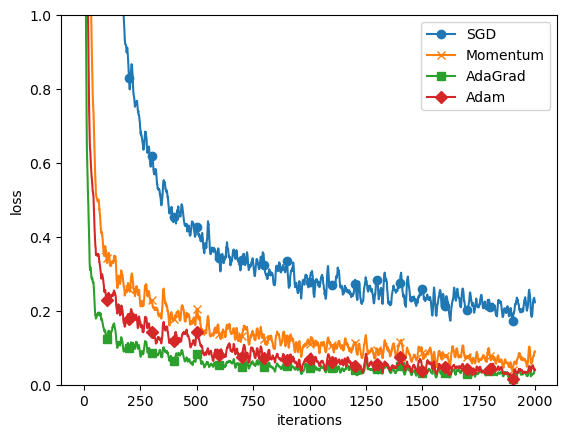

In [3]:
# coding: utf-8
import os
import sys
sys.path.append(os.pardir)
import matplotlib.pyplot as plt
from mnist import load_mnist
from common.util import smooth_curve, shuffle_dataset
from common.multi_layer_net import MultiLayerNet
from common.optimizer import *



(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000



optimizers = {}
optimizers['SGD'] = SGD()
optimizers['Momentum'] = Momentum()
optimizers['AdaGrad'] = AdaGrad()
optimizers['Adam'] = Adam()
#optimizers['RMSprop'] = RMSprop()

networks = {}
train_loss = {}
for key in optimizers.keys():
    networks[key] = MultiLayerNet(
        input_size=784, hidden_size_list=[100, 100, 100, 100],
        output_size=10)
    train_loss[key] = []



for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    for key in optimizers.keys():
        grads = networks[key].gradient(x_batch, t_batch)
        optimizers[key].update(networks[key].params, grads)

        loss = networks[key].loss(x_batch, t_batch)
        train_loss[key].append(loss)

    if i % 100 == 0:
        print( "===========" + "iteration:" + str(i) + "===========")
        for key in optimizers.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key + ":" + str(loss))



markers = {"SGD": "o", "Momentum": "x", "AdaGrad": "s", "Adam": "D"}
x = np.arange(max_iterations)
for key in optimizers.keys():
    plt.plot(x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 1)
plt.legend()
plt.show()






借助MNIST数据集，我们也能看出随着迭代次数的增加，各个方法的效果

### 2.权重的初始值

为了避免过拟合，提高泛化能力，我们最后应该逐渐减小权值参数的值，但可不可以一开始就将其全设置为零呢，答案是否定的，我们甚至不能将权重参数设置为相同的值，假设一个2层的神经网络，当输入层输入数据时，由于权重为0，那么第二层的神经元会得到相同的值，意味着反向传播时第二层的权重会进行相同的更新，这导致最后所有权重都有相同的值，那利用权重来决定数据重要性的能力就丧失了，所以必须随机生成初始值

下面我们来看看权重参数的初始值是怎么影响的

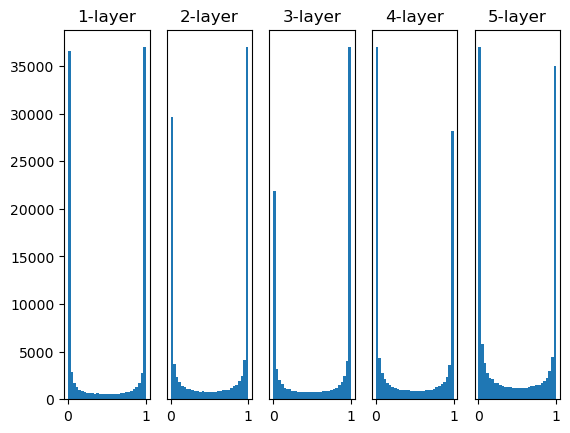

In [7]:

import numpy as np
import matplotlib.pyplot as plt


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def ReLU(x):
    return np.maximum(0, x)


def tanh(x):
    return np.tanh(x)

input_data = np.random.randn(1000, 100)
node_num = 100
hidden_layer_size = 5
activations = {}

x = input_data

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1]


    w = np.random.randn(node_num, node_num) * 1#注意这里的系数是1，下个例子我将改为0.01
    # w = np.random.randn(node_num, node_num) * 0.01
    # w = np.random.randn(node_num, node_num) * np.sqrt(1.0 / node_num)
    # w = np.random.randn(node_num, node_num) * np.sqrt(2.0 / node_num)


    a = np.dot(x, w)



    z = sigmoid(a)
    # z = ReLU(a)
    # z = tanh(a)

    activations[i] = z


for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    if i != 0: plt.yticks([], [])
    # plt.xlim(0.1, 1)
    # plt.ylim(0, 7000)
    plt.hist(a.flatten(), 30, range=(0,1))
plt.show()


借用一个五层神经网络，不同层的输出值可以看到，利用sigmoid函数作为激活函数时，输出值集中在0，1附近，这导致我们在使用反向传播求梯度时，最后得到的是极小的值(由于sigmoid导数的特性，其导数最大值不超过0.25，而反向传播的过程其实就是一个导数连乘的过程，连乘极小值，导致梯度很小)，这样导致权重参数根本改变不了什么，我们把这种现象称为梯度消失，所以这也是为什么现在神经网络不用sigmoid而改用ReLu

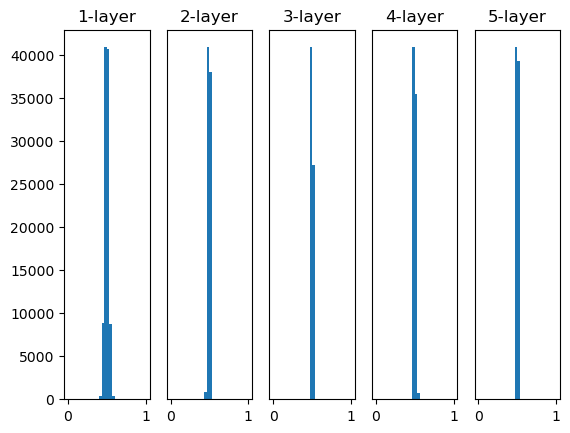

In [8]:

import numpy as np
import matplotlib.pyplot as plt


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def ReLU(x):
    return np.maximum(0, x)


def tanh(x):
    return np.tanh(x)

input_data = np.random.randn(1000, 100)
node_num = 100
hidden_layer_size = 5
activations = {}

x = input_data

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1]


   # w = np.random.randn(node_num, node_num) * 1#注意这里的系数是1，下个例子我将改为0.01
    w = np.random.randn(node_num, node_num) * 0.01
    # w = np.random.randn(node_num, node_num) * np.sqrt(1.0 / node_num)
    # w = np.random.randn(node_num, node_num) * np.sqrt(2.0 / node_num)


    a = np.dot(x, w)



    z = sigmoid(a)
    # z = ReLU(a)
    # z = tanh(a)

    activations[i] = z


for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    if i != 0: plt.yticks([], [])
    # plt.xlim(0.1, 1)
    # plt.ylim(0, 7000)
    plt.hist(a.flatten(), 30, range=(0,1))
plt.show()
#比较上面的代码，我仅仅是将w初始化的范围缩小了100倍，但激活值的大小却完全不同

可以看到，这次的激活值几乎全部堆积到0.5左右，虽然不会发生梯度消失，但是多个神经元都输出几乎相同的值，这也没有意义，因为我明明可以用一个神经元做到，这就是被称作“表现力受限”的问题，为了避免梯度消失和表现力受限，我们要在各层间传递多样性的数据

2. Xavier初始值：下面同样是一样的神经网络，我们用Xavier初始值试试(如果上一层有n个神经元，那么这一初始值就用标准差为$\sqrt{n}$的分布)

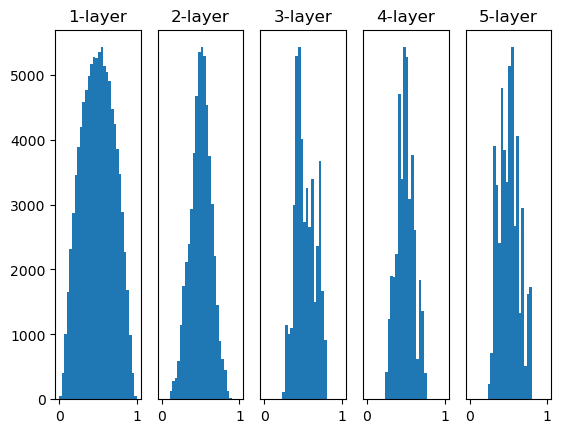

In [9]:

import numpy as np
import matplotlib.pyplot as plt


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def ReLU(x):
    return np.maximum(0, x)


def tanh(x):
    return np.tanh(x)

input_data = np.random.randn(1000, 100)
node_num = 100
hidden_layer_size = 5
activations = {}

x = input_data

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1]


   # w = np.random.randn(node_num, node_num) * 1#注意这里的系数是1，下个例子我将改为0.01
   # w = np.random.randn(node_num, node_num) * 0.01
    w = np.random.randn(node_num, node_num) * np.sqrt(1.0 / node_num)
    # w = np.random.randn(node_num, node_num) * np.sqrt(2.0 / node_num)


    a = np.dot(x, w)



    z = sigmoid(a)
    # z = ReLU(a)
    # z = tanh(a)

    activations[i] = z


for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    if i != 0: plt.yticks([], [])
    # plt.xlim(0.1, 1)
    # plt.ylim(0, 7000)
    plt.hist(a.flatten(), 30, range=(0,1))
plt.show()
#比较上面的代码，我仅仅是将w初始化的范围缩小了100倍，但激活值的大小却完全不同

虽然后面的层有些歪斜，但是提升了分布的广度，大大加强了表现力

3. ReLu函数的初始值

Xavier适用于sigmoid和tanh函数，因为它们左右对称且中央附近可以视作线性函数，但是ReLU不一样，非线性，使用He初始值：当前一个层神经元数量为n时，He初始值使用标准差为$\frac{2}{\sqrt{n}}$的高斯分布，下面我们来对比一下std=0.01，Xavier和He三种不同初始值下的结果

===========iteration:0===========
std=0.01:2.3025325445176827
Xavier:2.307290215174179
He:2.2982516909616715
===========iteration:100===========
std=0.01:2.301675455854495
Xavier:2.2726048601022857
He:1.6424800025631678
===========iteration:200===========
std=0.01:2.301687287246469
Xavier:2.120599426183534
He:0.8687362966580958
===========iteration:300===========
std=0.01:2.30303081181344
Xavier:1.9573420837229687
He:0.5016734750841603
===========iteration:400===========
std=0.01:2.3011973171955047
Xavier:1.5973461419173953
He:0.4407174709521069
===========iteration:500===========
std=0.01:2.2999147859798414
Xavier:1.1277816460349985
He:0.35224913362533883
===========iteration:600===========
std=0.01:2.2990160327088818
Xavier:0.7006374552491637
He:0.3239849326544936
===========iteration:700===========
std=0.01:2.303147270278949
Xavier:0.5458393904853999
He:0.2516085370622859
===========iteration:800===========
std=0.01:2.2997627990060288
Xavier:0.5072307754508396
He:0.31216160818602523

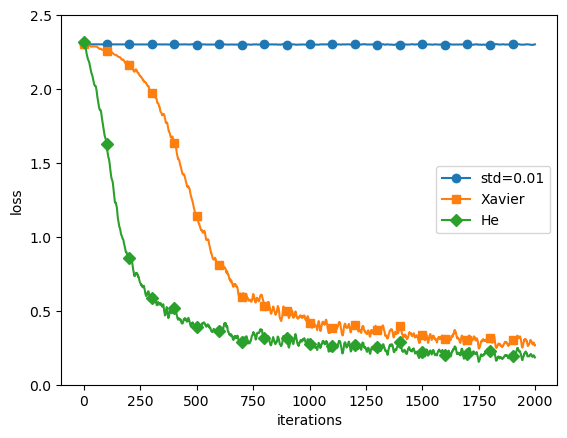

In [10]:

import os
import sys

sys.path.append(os.pardir)
import numpy as np
import matplotlib.pyplot as plt
from mnist import load_mnist
from common.util import smooth_curve
from common.multi_layer_net import MultiLayerNet
from common.optimizer import SGD



(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000



weight_init_types = {'std=0.01': 0.01, 'Xavier': 'sigmoid', 'He': 'relu'}
optimizer = SGD(lr=0.01)

networks = {}
train_loss = {}
for key, weight_type in weight_init_types.items():
    networks[key] = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100],
                                  output_size=10, weight_init_std=weight_type)
    train_loss[key] = []



for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    for key in weight_init_types.keys():
        grads = networks[key].gradient(x_batch, t_batch)
        optimizer.update(networks[key].params, grads)

        loss = networks[key].loss(x_batch, t_batch)
        train_loss[key].append(loss)

    if i % 100 == 0:
        print("===========" + "iteration:" + str(i) + "===========")
        for key in weight_init_types.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key + ":" + str(loss))



markers = {'std=0.01': 'o', 'Xavier': 's', 'He': 'D'}
x = np.arange(max_iterations)
for key in weight_init_types.keys():
    plt.plot(x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 2.5)
plt.legend()
plt.show()

果然He初始值下的学习速度最快，由上述可知，权重的初始值十分重要！！！！

### 3.Batch Normalization

由上述例子我们可以看见，激活函数值的分布的广度会影响模型的表达能力，Batch normalization就是一种“强制性”调整激活值的分布的方法，它的优点如下：
1. 增大学习率，加快学习速度
2. 不那么依赖初始值
3. 抑制过拟合

实现原理也很简单，将输入数据变为均值为零，方差为1的数据集，放在激活函数的前面或者后面都可以，这样能明显降低数据的倾向

### Batch Normalization 核心算法

Batch Normalization (BN) 通过对每个 mini-batch 的数据进行标准化，并引入可学习的参数来恢复数据的表达能力。

#### 1. 计算 Mini-batch 的均值和方差
对于当前 mini-batch 的输入 $\mathcal{B} = \{x_1, ..., x_m\}$（其中 $m$ 是 batch size），首先计算均值 $\mu_\mathcal{B}$ 和方差 $\sigma_\mathcal{B}^2$：

$$
\mu_\mathcal{B} = \frac{1}{m} \sum_{i=1}^{m} x_i
$$

$$
\sigma_\mathcal{B}^2 = \frac{1}{m} \sum_{i=1}^{m} (x_i - \mu_\mathcal{B})^2
$$

#### 2. 标准化 (Normalization)
使用计算出的均值和方差对输入数据进行标准化。$\epsilon$ 是一个极小的常数（如 $1e-5$），用于防止分母为 0：

$$
\hat{x}_i = \frac{x_i - \mu_\mathcal{B}}{\sqrt{\sigma_\mathcal{B}^2 + \epsilon}}
$$

#### 3. 缩放与偏移 (Scale and Shift)
引入两个**可学习的参数**：缩放因子 $\gamma$ (weight) 和平移因子 $\beta$ (bias)，得到最终输出 $y_i$：

$$
y_i = \gamma \hat{x}_i + \beta \quad \text{}
$$

---

#### 训练态与推理态的区别

| 阶段 | 均值与方差的来源 | 说明 |
| :--- | :--- | :--- |
| **训练阶段 (Training)** | 使用**当前 mini-batch** 的统计量 | 同时通过**滑动平均**更新全局统计量。 |
| **推理阶段 (Inference)** | 使用**训练时累积的全局**统计量 | 推理时不再依赖当前 batch，保证分布固定。 |

我们来感受一下

============== 1/16 ==============
epoch:0 | 0.117 - 0.1
epoch:1 | 0.097 - 0.121
epoch:2 | 0.097 - 0.135
epoch:3 | 0.116 - 0.159
epoch:4 | 0.116 - 0.175
epoch:5 | 0.116 - 0.203
epoch:6 | 0.116 - 0.224
epoch:7 | 0.116 - 0.238
epoch:8 | 0.116 - 0.257
epoch:9 | 0.116 - 0.274
epoch:10 | 0.116 - 0.289
epoch:11 | 0.117 - 0.307
epoch:12 | 0.117 - 0.328
epoch:13 | 0.117 - 0.337
epoch:14 | 0.117 - 0.363
epoch:15 | 0.117 - 0.384
epoch:16 | 0.117 - 0.4
epoch:17 | 0.117 - 0.412
epoch:18 | 0.117 - 0.419
epoch:19 | 0.117 - 0.448
============== 2/16 ==============
epoch:0 | 0.099 - 0.084
epoch:1 | 0.097 - 0.146


C:\Users\Yu\AppData\Local\Temp\ipykernel_38632\3159531672.py:82: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right')
D:\Users\Yu\pythonlearning\PythonProject1\common\layers.py:57: RuntimeWarning: overflow encountered in dot
  out = np.dot(self.x, self.W) + self.b
D:\Users\Yu\pythonlearning\PythonProject1\common\functions.py:32: RuntimeWarning: invalid value encountered in subtract
  x = x - np.max(x, axis=-1, keepdims=True)   # オーバーフロー対策


epoch:2 | 0.097 - 0.19
epoch:3 | 0.097 - 0.215
epoch:4 | 0.097 - 0.24
epoch:5 | 0.097 - 0.262
epoch:6 | 0.097 - 0.277
epoch:7 | 0.097 - 0.297
epoch:8 | 0.097 - 0.315
epoch:9 | 0.097 - 0.329
epoch:10 | 0.097 - 0.348
epoch:11 | 0.097 - 0.377
epoch:12 | 0.097 - 0.389
epoch:13 | 0.097 - 0.402
epoch:14 | 0.097 - 0.433
epoch:15 | 0.097 - 0.438
epoch:16 | 0.097 - 0.459
epoch:17 | 0.097 - 0.466
epoch:18 | 0.097 - 0.492
epoch:19 | 0.097 - 0.497
============== 3/16 ==============
epoch:0 | 0.129 - 0.096
epoch:1 | 0.329 - 0.079
epoch:2 | 0.459 - 0.115
epoch:3 | 0.577 - 0.144
epoch:4 | 0.645 - 0.189
epoch:5 | 0.7 - 0.227
epoch:6 | 0.744 - 0.276
epoch:7 | 0.785 - 0.319
epoch:8 | 0.808 - 0.352
epoch:9 | 0.843 - 0.393
epoch:10 | 0.867 - 0.417
epoch:11 | 0.889 - 0.448
epoch:12 | 0.908 - 0.465
epoch:13 | 0.922 - 0.498
epoch:14 | 0.939 - 0.518
epoch:15 | 0.949 - 0.547
epoch:16 | 0.956 - 0.555
epoch:17 | 0.964 - 0.575
epoch:18 | 0.965 - 0.598
epoch:19 | 0.977 - 0.615
============== 4/16 ==============
ep

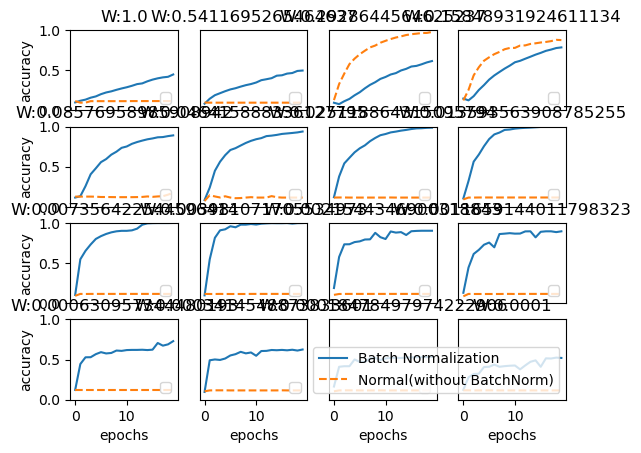

In [1]:
# coding: utf-8
import sys, os
sys.path.append(os.pardir)  #
import numpy as np
import matplotlib.pyplot as plt
from mnist import load_mnist
from common.multi_layer_net_extend import MultiLayerNetExtend
from common.optimizer import SGD, Adam

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)
x_train = x_train[:1000]
t_train = t_train[:1000]

max_epochs = 20
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.01


def __train(weight_init_std):
    bn_network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10,
                                    weight_init_std=weight_init_std, use_batchnorm=True)
    network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10,
                                weight_init_std=weight_init_std)
    optimizer = SGD(lr=learning_rate)

    train_acc_list = []
    bn_train_acc_list = []

    iter_per_epoch = max(train_size / batch_size, 1)
    epoch_cnt = 0

    for i in range(1000000000):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]

        for _network in (bn_network, network):
            grads = _network.gradient(x_batch, t_batch)
            optimizer.update(_network.params, grads)

        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            bn_train_acc = bn_network.accuracy(x_train, t_train)
            train_acc_list.append(train_acc)
            bn_train_acc_list.append(bn_train_acc)

            print("epoch:" + str(epoch_cnt) + " | " + str(train_acc) + " - " + str(bn_train_acc))

            epoch_cnt += 1
            if epoch_cnt >= max_epochs:
                break

    return train_acc_list, bn_train_acc_list


weight_scale_list = np.logspace(0, -4, num=16)
x = np.arange(max_epochs)

for i, w in enumerate(weight_scale_list):
    print( "============== " + str(i+1) + "/16" + " ==============")
    train_acc_list, bn_train_acc_list = __train(w)

    plt.subplot(4,4,i+1)
    plt.title("W:" + str(w))
    if i == 15:
        plt.plot(x, bn_train_acc_list, label='Batch Normalization', markevery=2)
        plt.plot(x, train_acc_list, linestyle = "--", label='Normal(without BatchNorm)', markevery=2)
    else:
        plt.plot(x, bn_train_acc_list, markevery=2)
        plt.plot(x, train_acc_list, linestyle="--", markevery=2)

    plt.ylim(0, 1.0)
    if i % 4:
        plt.yticks([])
    else:
        plt.ylabel("accuracy")
    if i < 12:
        plt.xticks([])
    else:
        plt.xlabel("epochs")
    plt.legend(loc='lower right')

plt.show()

可以看到使用了BAtch-normalization的效果好得多，而不使用的，甚至不能正常学习

### 4.正则化

- 过拟合

过拟合的出现是由于参数过多或者数据过少，导致对某一训练集数据预测结果好，但是对其他数据效果极差，泛化能力下降的现象，我们可以制造过拟合现象

In [ ]:

import os
import sys

sys.path.append(os.pardir)
import numpy as np
import matplotlib.pyplot as plt
from mnist import load_mnist
from common.multi_layer_net import MultiLayerNet
from common.optimizer import SGD

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

x_train = x_train[:300]
t_train = t_train[:300]


weight_decay_lambda = 0

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=weight_decay_lambda)
optimizer = SGD(lr=0.01)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

这个例子中，我们将数据设置地很少，可以看到，对于训练集而言，准确率可以达到很高几乎百分百，但是对于测试集，拟合度相当低，这就是过拟合现象

- 抑制过拟合的方法

1. 权值衰减法

一般常用的是L2范数，当然也有L1（绝对值之和）,L2范数的机制是让损失函数加上二分之一倍的所有元素的平方和
$$
\|x\|_2 = \sqrt{\sum_{i=1}^{n} x_i^2} = \sqrt{x_1^2 + x_2^2 + \cdots + x_n^2}
$$
$$
J_{total}(w) = J(w) + \lambda \sum_{i=1}^{n} w_i^2 = J(w) + \lambda \|w\|_2^2
$$

这样的话，模型考虑损失函数时，不仅要考虑拟合程度，还要想办法降低参数的个数及大小，同时由于所有权重参数都会为损失函数加上二分之一λ平方和，所以在反向传播计算梯度的过程中要为结果乘上λW，λ是一个超参数，用来控制对过拟合的惩罚力度，下面是λ取0.1时的图像

epoch:0, train acc:0.12333333333333334, test acc:0.1079
epoch:1, train acc:0.13666666666666666, test acc:0.1109
epoch:2, train acc:0.14666666666666667, test acc:0.1267
epoch:3, train acc:0.16333333333333333, test acc:0.136
epoch:4, train acc:0.17666666666666667, test acc:0.1471
epoch:5, train acc:0.20666666666666667, test acc:0.1609
epoch:6, train acc:0.24, test acc:0.173
epoch:7, train acc:0.29333333333333333, test acc:0.1897
epoch:8, train acc:0.31333333333333335, test acc:0.2066
epoch:9, train acc:0.33666666666666667, test acc:0.2183
epoch:10, train acc:0.38, test acc:0.2345
epoch:11, train acc:0.39666666666666667, test acc:0.2513
epoch:12, train acc:0.4033333333333333, test acc:0.2635
epoch:13, train acc:0.42, test acc:0.2868
epoch:14, train acc:0.44333333333333336, test acc:0.2926
epoch:15, train acc:0.44333333333333336, test acc:0.3002
epoch:16, train acc:0.43666666666666665, test acc:0.3103
epoch:17, train acc:0.43666666666666665, test acc:0.3211
epoch:18, train acc:0.4466666666

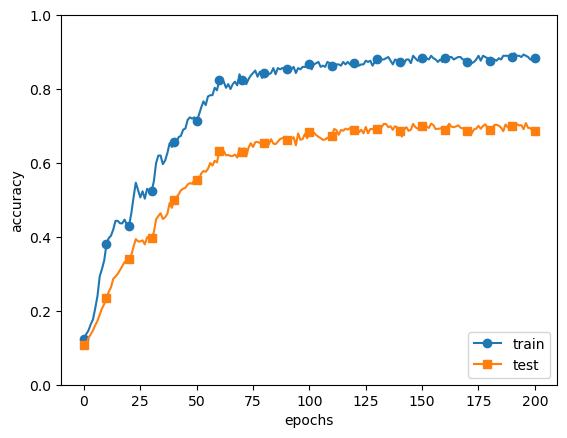

In [4]:

import os
import sys

sys.path.append(os.pardir)
import numpy as np
import matplotlib.pyplot as plt
from mnist import load_mnist
from common.multi_layer_net import MultiLayerNet
from common.optimizer import SGD

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

x_train = x_train[:300]
t_train = t_train[:300]


weight_decay_lambda = 0.1

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=weight_decay_lambda)
optimizer = SGD(lr=0.01)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()


可以看到，虽然对训练集的准确率低了，但是训练集与测试集之间的差距变小了，说明过拟合现象受到了抑制

2. Dropout方法

处理简单神经网络时权重衰减法可以起作用，但是复杂的神经网络中，Dropout方法会更好，它的原理是在训练过程中随机删除隐藏层的神经元，被删除的神经元就不再输出结果，虽然传递时传递所有的神经信号，但是输出时要乘以训练时的删除比例后再输出(图在P193,看图非常清晰)，可以理解为教练在平时的训练中，会随机让某些球员下场休息。这就迫使剩下的球员不能过度依赖某一个人，每个人都必须学会独当一面，掌握多种配合方式。等到正式比赛（测试阶段）全员上场时，整支球队的配合就会非常稳健，适应各种突发情况。下面是代码实现

In [5]:
class Dropout:
    def __init__(self,rate=0.5):
        self.rate = rate
        self.mask=None
    def forward(self,x,train_flat=True):
        if train_flat:
            self.mask=np.random.rand(*x.shape)>self.rate#生成一个掩阵，形状和x一样，大小在0到1之间，然后和0.5比较，大于0.5的变为True,否则变为False
            return x*self.mask#将输入数据与其相乘，就实现了删除部分神经元
        else:
            return x*(1.0-self.rate)
    def backward(self,dout):
        return dout*self.mask

In [ ]:
# coding: utf-8
import os
import sys
sys.path.append(os.pardir)
import numpy as np
import matplotlib.pyplot as plt
from mnist import load_mnist
from common.multi_layer_net_extend import MultiLayerNetExtend
from common.trainer import Trainer

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)


x_train = x_train[:300]
t_train = t_train[:300]


use_dropout = True
dropout_ratio = 0.1
# ====================================================

network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                              output_size=10, use_dropout=use_dropout, dropout_ration=dropout_ratio)
trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=301, mini_batch_size=100,
                  optimizer='sgd', optimizer_param={'lr': 0.01}, verbose=True)
trainer.train()

train_acc_list, test_acc_list = trainer.train_acc_list, trainer.test_acc_list


markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

我们在机器学习中常常使用集成学习，即用不同的模型(即使用多个相似结构的神经网络)得出结果然后求平均值，这样的结果会使最后的准确率高上几个百分点，dropout之所以可以提高效率，就是因为其随机舍弃的属性，创造出类似于不同神经网络学习的作用，近乎于实现了集成学习

### 5.超参数的验证

- 超参数的验证不能使用训练集，因为这样会导致超参数的值出现过拟合，导致泛化能力降低，因此，我们可以将初始数据分为三类,即训练集，测试集，验证集。验证集就是验证超参数的数据，代码如下：


In [ ]:
(x_train,t_train), (x_test, t_test) = load_mnist()
#打乱数据,为了避免出现数据存在偏向
x_train,t_train=shuffle_dataset(x_train,t_train)
#分割数据
validation_rate=0.20
validation_num=int(x_train.shape[0]*validation_rate)
x_val=x_train[:validation_num]
t_val=t_train[:validation_num]
x_train=x_train[:validation_rate]
t_train=t_train[:validation_rate]


- 超参数的最优化

1. 确定一个范围
2. 后在范围里随机选出一个采样
3. 根据结果缩小范围(要将epoch设置的很小，因为深度学习要耗费很长时间，我们应该尽快舍弃不好的超参数)
4. 重复

实现代码如下：

val acc:0.09 | lr:1.8310737451424255e-06, weight decay:1.6077297066279704e-08
val acc:0.08 | lr:0.0005940876424635576, weight decay:2.2046540336905545e-05
val acc:0.09 | lr:2.009586358686204e-06, weight decay:4.6134692850545676e-05
val acc:0.67 | lr:0.004095516600928906, weight decay:1.1500515438827083e-08
val acc:0.24 | lr:0.0012692329011286258, weight decay:6.985228413731945e-05
val acc:0.08 | lr:3.7288263588869196e-05, weight decay:1.508194252901392e-07
val acc:0.65 | lr:0.005899292781573521, weight decay:4.7568539233734983e-07
val acc:0.09 | lr:5.281225696599822e-05, weight decay:8.221657731309445e-06
val acc:0.81 | lr:0.008942646047646545, weight decay:1.5730189948353417e-06
val acc:0.09 | lr:0.0002272053096991294, weight decay:5.852381506795888e-07
val acc:0.43 | lr:0.003965784591458043, weight decay:1.8598371115797383e-07
val acc:0.16 | lr:0.0005025294947054172, weight decay:1.2874462112051104e-07
val acc:0.12 | lr:9.649060744121284e-05, weight decay:7.053515471691667e-06
val ac

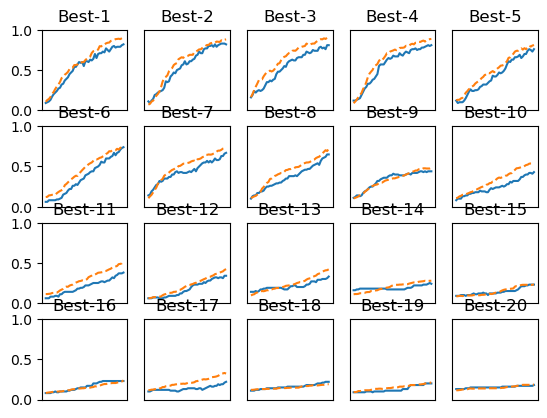

In [1]:
# coding: utf-8
import sys, os
sys.path.append(os.pardir)  # 为了导入父目录中的文件而进行的设定
import numpy as np
import matplotlib.pyplot as plt
from mnist import load_mnist
from common.multi_layer_net import MultiLayerNet
from common.util import shuffle_dataset
from common.trainer import Trainer

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 为了加快处理速度，削减训练数据
x_train = x_train[:500]
t_train = t_train[:500]

# 分离验证数据
validation_rate = 0.20
validation_num = int(x_train.shape[0] * validation_rate)
x_train, t_train = shuffle_dataset(x_train, t_train)
x_val = x_train[:validation_num]
t_val = t_train[:validation_num]
x_train = x_train[validation_num:]
t_train = t_train[validation_num:]


def __train(lr, weight_decay, epocs=50):
    network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                            output_size=10, weight_decay_lambda=weight_decay)
    trainer = Trainer(network, x_train, t_train, x_val, t_val,
                      epochs=epocs, mini_batch_size=100,
                      optimizer='sgd', optimizer_param={'lr': lr}, verbose=False)
    trainer.train()

    return trainer.test_acc_list, trainer.train_acc_list


# 超参数的随机探索======================================
optimization_trial = 100
results_val = {}
results_train = {}
for _ in range(optimization_trial):
    # 指定探索的超参数范围===============
    weight_decay = 10 ** np.random.uniform(-8, -4)
    lr = 10 ** np.random.uniform(-6, -2)
    # ================================================

    val_acc_list, train_acc_list = __train(lr, weight_decay)
    print("val acc:" + str(val_acc_list[-1]) + " | lr:" + str(lr) + ", weight decay:" + str(weight_decay))
    key = "lr:" + str(lr) + ", weight decay:" + str(weight_decay)
    results_val[key] = val_acc_list
    results_train[key] = train_acc_list

# 绘制图表========================================================
print("=========== Hyper-Parameter Optimization Result ===========")
graph_draw_num = 20
col_num = 5
row_num = int(np.ceil(graph_draw_num / col_num))
i = 0

for key, val_acc_list in sorted(results_val.items(), key=lambda x:x[1][-1], reverse=True):
    print("Best-" + str(i+1) + "(val acc:" + str(val_acc_list[-1]) + ") | " + key)

    plt.subplot(row_num, col_num, i+1)
    plt.title("Best-" + str(i+1))
    plt.ylim(0.0, 1.0)
    if i % 5: plt.yticks([])
    plt.xticks([])
    x = np.arange(len(val_acc_list))
    plt.plot(x, val_acc_list)
    plt.plot(x, results_train[key], "--")
    i += 1

    if i >= graph_draw_num:
        break

plt.show()